In [1]:
import platform
if 'mac' in platform.platform():
    BASE_DIR = "/Users/USER/vrtopc/"
    DATA_DIR = "/media/data/vrtopc"
else:
    BASE_DIR = "/home/USER/vr_to_pc/"
    DATA_DIR = "/media/data/vrtopc"

import sys
sys.path.append(BASE_DIR)

### Imports

In [ ]:
import torch
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

from utils.metrics import get_spatial_correlation

import scipy
import pandas as pd
import numpy as np
import os
import yaml
import matplotlib.pyplot as plt
from tqdm import tqdm

# Processed data for the Science and Muessig papers

### Parameters

In [3]:
from utils.spatial_units import RateMaps, PolarMaps

N_SAMPLES_POS = RateMaps.N_SAMPLES_POS
PLACE_SI_TH = RateMaps.PLACE_SI_TH

N_SAMPLES_THET = PolarMaps.N_SAMPLES_THET
HD_SI_TH = PolarMaps.HD_SI_TH
HD_RVL_TH = PolarMaps.HD_RVL_TH


In [ ]:
edge_n_bins = 4

ONLY_2ND_TRIAL = True

AGES_TO_REMOVE = list(range(26, 32 +1))

SAVE_PLOTS = False
SAVE_DIR = None

### Load Data

In [5]:
ratnames_science = []
ratnames_muessig = []

data_dir = os.path.join(DATA_DIR, 'real_data', 'science2010_data_struct')
data = {}
for file in os.listdir(data_dir):
    if file.endswith('.mat'):
        name = file.split('.')[0].lower()
        if 'shuffled' in name:
            name += '_science2010'
        else:
            ratnames_science.append(name)
        data[name] = scipy.io.loadmat(os.path.join(data_dir, file))

data_dir = os.path.join(DATA_DIR, 'real_data', 'muessig_data_struct')
for file in os.listdir(data_dir):
    if file.endswith('.mat'):
        name = file.split('.')[0].lower()
        if 'shuffled' in name:
            name += '_muessig'
        else:
            ratnames_muessig.append(name)
            
        if name in data.keys():
            raise ValueError(f"Duplicate file name: {name}")
        data[name] = scipy.io.loadmat(os.path.join(data_dir, file))

sorted(list(data.keys()))[:5]

['r101_p20', 'r104_p26', 'r112_p40', 'r115_p24', 'r118_p24']

In [6]:
def get(x):
    return x[0][0]

data_dict = {}
ratnames_old = []

for k in data.keys():
    print(k)

    if not k.startswith('r'):
        print(f"File name {k} does not start with 'r', skipping")
        continue

    ratname = k
    
    if ratname not in data_dict.keys():
        data_dict[ratname] = {}
    
    d = get(data[k]['tmpS'])
    d_keys = list(d.dtype.names)

    dataset = d[d_keys.index('dataset')][0].split('_')[-1]
    ratnames_old.append(f"{ratname}_{dataset}")

    # sample rate is always 50 Hz
    ages = d[d_keys.index('age')][0] # age 40 denotes adult
    ages = [a if a<100 else 40 for a in ages]

    sample_rates = d[d_keys.index('sampleRate')][0]
    env_types = d[d_keys.index('envType')][0]
    ppm = d[d_keys.index('ppm')][0]
    spike_times = d[d_keys.index('spikeTimes')][0]
    is_cs_neuron = d[d_keys.index('isCSNeuron')][0]
    has_min_freq = d[d_keys.index('hasMinFreq')][0]
    pos = d[d_keys.index('positions')][0]
    hd = d[d_keys.index('directions')][0] # degrees
    speed = d[d_keys.index('speed')][0] # cm/s

    rate_maps = d[d_keys.index('rateMaps')][0]
    pos_occ = d[d_keys.index('posOccMaps')][0]
    si = d[d_keys.index('SI')][0]
    rate_maps_corr = d[d_keys.index('corrRateMaps')][0]
    si_corr = d[d_keys.index('SICorr')][0]
    rate_maps_hd8 = d[d_keys.index('rateMapsHD8')][0]
    rate_maps_hd4 = d[d_keys.index('rateMapsHD4')][0]
    
    polar_maps = d[d_keys.index('polarMaps')][0]
    si_pm = d[d_keys.index('dirSI')][0]
    rvl = d[d_keys.index('rvLength')][0]
    hd_occ = d[d_keys.index('dirOccMaps')][0]
    polar_maps_corr = d[d_keys.index('corrPolarMaps')][0]
    si_pm_corr = d[d_keys.index('dirSICorr')][0]
    rvl_corr = d[d_keys.index('rvLengthCorr')][0]
    polar_maps_pred = d[d_keys.index('predPolarMaps')][0]
    dis_ratios = d[d_keys.index('disRatios')][0]

    # there are always max 3 trials per day
    n_trials = 0
    for trial_n in range(len(ages)):
        if ONLY_2ND_TRIAL and (trial_n != 1) : continue # keep second trial

        rms = rate_maps[trial_n]
        sis = si[trial_n]
        rms_corr = rate_maps_corr[trial_n]
        sis_corr = si_corr[trial_n]
        rms_hd8 = rate_maps_hd8[trial_n]
        rms_hd4 = rate_maps_hd4[trial_n]

        pms = polar_maps[trial_n]
        sis_pm = si_pm[trial_n]
        rvls = rvl[trial_n]
        pms_corr = polar_maps_corr[trial_n]
        sis_pm_corr = si_pm_corr[trial_n]
        rvls_corr = rvl_corr[trial_n]
        drs = dis_ratios[trial_n]
        pms_pred = polar_maps_pred[trial_n]
        if rms.shape[-1] == 0 or pms.shape[-1] == 0:
            print(f"Skipping trial {trial_n} because rate maps or polar maps are empty")
            continue

        t = {}
        age = ages[trial_n]
        env = env_types[trial_n][0]
        p = pos[trial_n]
    
        if np.isnan(age) and (len(env) == 0) and (p.shape[-1] == 0):
            continue
        n_trials += 1

        age = int(age)
        if age not in data_dict[ratname].keys():
            data_dict[ratname][age] = {}
            data_dict[ratname][age]['trials'] = []

        t['name'] = n_trials
        t['environment'] = env
        t['ppm'] = ppm
        t['sample_rate'] = sample_rates[trial_n] # Hz
        t['positions'] = p
        t['x'] = p[:,0]
        t['y'] = p[:,1]
        if ratname in ratnames_science:
            t['spike_times'] = spike_times[trial_n][0]
            t['is_cs_neuron'] = is_cs_neuron[trial_n][0]
            t['has_min_freq'] = has_min_freq[trial_n][0]
        else:
            t['spike_times'] = spike_times[trial_n].squeeze() if len(spike_times[trial_n])>1 else spike_times[trial_n][0]
            t['is_cs_neuron'] = is_cs_neuron[trial_n].squeeze() if len(is_cs_neuron[trial_n])>1 else is_cs_neuron[trial_n][0]
            t['has_min_freq'] = has_min_freq[trial_n].squeeze() if len(has_min_freq[trial_n])>1 else has_min_freq[trial_n][0]

        t['speed'] = speed[trial_n].squeeze()/100 # m/s
        t['hd'] = hd[trial_n].squeeze()
        t['duration'] = len(t['x'])/t['sample_rate']

        # convert to (n_units, n_bins, n_bins)
        t['rate_maps'] = np.array([rms[idx][0] for idx in range(len(rms))])
        t['si'] = np.array([sis[idx][0] for idx in range(len(sis))])
        t['rate_maps_corr'] = np.array([rms_corr[idx][0] for idx in range(len(rms_corr))])
        t['si_corr'] = np.array([sis_corr[idx][0] for idx in range(len(sis_corr))])

        rms_hd_np8 = np.zeros((t['rate_maps'].shape[0], 8, t['rate_maps'].shape[-1], t['rate_maps'].shape[-1]))
        rms_hd_np4 = np.zeros((t['rate_maps'].shape[0], 4, t['rate_maps'].shape[-1], t['rate_maps'].shape[-1]))
        for j in range(8):
            if j < 4:
                rms_hd_np4[:, j, ...] = np.array(
                    [get(rms_hd4[idx])[j] for idx in range(len(rms_hd4))]
                )
            rms_hd_np8[:, j, ...] = np.array(
                [get(rms_hd8[idx])[j] for idx in range(len(rms_hd8))]
            )
        # convert to (n_units, 8, n_bins, n_bins)
        t['rate_maps_hd8'] = rms_hd_np8
        t['rate_maps_hd4'] = rms_hd_np4

        # convert to (n_units, n_bins)
        t['polar_maps'] = np.array([pms[idx][0] for idx in range(len(pms))])[..., 0]
        t['si_pm'] = np.array([sis_pm[idx][0] for idx in range(len(sis_pm))])
        t['rvl'] = np.array([rvls[idx][0] for idx in range(len(rvls))])
        t['polar_maps_corr'] = np.array([pms_corr[idx][0] for idx in range(len(pms_corr))])[..., 0]
        t['si_pm_corr'] = np.array([sis_pm_corr[idx][0] for idx in range(len(sis_pm_corr))])
        t['rvl_corr'] = np.array([rvls_corr[idx][0] for idx in range(len(rvls_corr))])

        t['polar_maps_pred'] = np.array([pms_pred[idx][0] for idx in range(len(pms_pred))])[..., 0]
        t['dis_ratios'] = np.array(drs[:,0])

        if t['rate_maps'].shape[0] != t['polar_maps'].shape[0]:
            raise ValueError(f"Rate maps ({t['rate_maps'].shape}) and polar maps ({t['polar_maps'].shape}) have different number of units")

        t['pos_occ'] = get(pos_occ[trial_n])
        t['hd_occ'] = np.array(hd_occ[trial_n][:,0])

        data_dict[ratname][age]['trials'].append(t)
    print(f"\t{n_trials} trial(s)")
    print()

r1308_d4
	1 trial(s)

r1526_p18
	1 trial(s)

r1343_d4
	1 trial(s)

r1526_p23
	1 trial(s)

r1343_d1
	1 trial(s)

r1589_p22
	1 trial(s)

r1589_p28
	1 trial(s)

r1333_d1
	1 trial(s)

r1477_p29
	1 trial(s)

r1552_p22
	1 trial(s)

r1637_p23
	1 trial(s)

r1588_p20
	1 trial(s)

r1589_p23
	1 trial(s)

r1589_p27
	1 trial(s)

r1588_p22
	1 trial(s)

r1515_p23
	1 trial(s)

r1589_p17
	1 trial(s)

r1589_p26
	1 trial(s)

r1552_p17
	1 trial(s)

r1308_d1
	1 trial(s)

r1526_p20
	1 trial(s)

r1589_p21
	1 trial(s)

r1552_p16_1
	1 trial(s)

r1589_p25
	1 trial(s)

r1333_d2
	1 trial(s)

r1628_p22_ca1
	1 trial(s)

r1589_p19
	1 trial(s)

r1515_p22
	1 trial(s)

r1526_p21
	1 trial(s)

r1588_p24
	1 trial(s)

r1474_p25
	1 trial(s)

r1552_p16_2
	1 trial(s)

r1588_p16
	1 trial(s)

shuffled_metrics_science2010
File name shuffled_metrics_science2010 does not start with 'r', skipping
shuffled_metrics_adult_science2010
File name shuffled_metrics_adult_science2010 does not start with 'r', skipping
r1588_p21
	1 trial(s)



In [7]:
ages = []
print('--------------------------------')
for k, v in data_dict.items():
    print(k)
    ages_tmp = list(v.keys())
    print('ages', ages_tmp)
    ages += ages_tmp
    print()
    print('--------------------------------')

--------------------------------
r1308_d4
ages [40]

--------------------------------
r1526_p18
ages [18]

--------------------------------
r1343_d4
ages [40]

--------------------------------
r1526_p23
ages [23]

--------------------------------
r1343_d1
ages [40]

--------------------------------
r1589_p22
ages [22]

--------------------------------
r1589_p28
ages [28]

--------------------------------
r1333_d1
ages [40]

--------------------------------
r1477_p29
ages [29]

--------------------------------
r1552_p22
ages [22]

--------------------------------
r1637_p23
ages [23]

--------------------------------
r1588_p20
ages [20]

--------------------------------
r1589_p23
ages [23]

--------------------------------
r1589_p27
ages [27]

--------------------------------
r1588_p22
ages [22]

--------------------------------
r1515_p23
ages [23]

--------------------------------
r1589_p17
ages [17]

--------------------------------
r1589_p26
ages [26]

--------------------------------

### Shuffled Threshold Extraction

In [8]:
metrics_shuffle_th_science = {}
metrics_shuffle_th_muessig = {}

for filename in data.keys():
    if not filename.startswith('shuffled'):
        continue
    print(filename)

    shuffled_si = data[filename]['shuffledSIByAge']
    shuffled_si_pm = data[filename]['shuffledDirSIByAge']
    shuffled_rvl = data[filename]['shuffledRVLByAge']
    for idx in range(len(shuffled_si)):
        for m, k in zip([shuffled_si, shuffled_si_pm, shuffled_rvl], ['SI', 'dirSI', 'rvLength']):
            m_curr = get(m[idx][0])
            keys = list(m_curr.dtype.names)
            age_group = get(m_curr[keys.index('ageGroup')])
            th = get(m_curr[keys.index(k+'Threshold')])

            if 'science' in filename.lower():
                if k not in metrics_shuffle_th_science.keys():
                    metrics_shuffle_th_science[k] = {}

                age = 14+age_group*2
                if age != 100:
                    metrics_shuffle_th_science[k][age] = th
                    metrics_shuffle_th_science[k][age+1] = th
                else : metrics_shuffle_th_science[k][40] = th
            elif 'muessig' in filename.lower():
                if k not in metrics_shuffle_th_muessig.keys():
                    metrics_shuffle_th_muessig[k] = {}

                age = 14+age_group*2
                if age != 100:
                    metrics_shuffle_th_muessig[k][age] = th
                    metrics_shuffle_th_muessig[k][age+1] = th
                else : metrics_shuffle_th_muessig[k][40] = th


shuffled_metrics_science2010
shuffled_metrics_adult_science2010
shuffled_metrics_muessig


In [9]:
print("SCIENCE 2010 THRESHOLDS")
for m in metrics_shuffle_th_science.keys():
    print(f"\n{m} thresholds")
    for a, th in metrics_shuffle_th_science[m].items():
        print(f"Age {a}: {th:.3f}")

print('\n')
print("LAURENZ THRESHOLDS")
for m in metrics_shuffle_th_muessig.keys():
    print(f"\n{m} thresholds")
    for a, th in metrics_shuffle_th_muessig[m].items():
        print(f"Age {a}: {th:.3f}")

SCIENCE 2010 THRESHOLDS

SI thresholds
Age 16: 0.319
Age 17: 0.319
Age 18: 0.400
Age 19: 0.400
Age 20: 0.391
Age 21: 0.391
Age 22: 0.369
Age 23: 0.369
Age 24: 0.346
Age 25: 0.346
Age 26: 0.291
Age 27: 0.291
Age 28: 0.299
Age 29: 0.299
Age 40: 0.513

dirSI thresholds
Age 16: 0.199
Age 17: 0.199
Age 18: 0.240
Age 19: 0.240
Age 20: 0.231
Age 21: 0.231
Age 22: 0.204
Age 23: 0.204
Age 24: 0.215
Age 25: 0.215
Age 26: 0.131
Age 27: 0.131
Age 28: 0.162
Age 29: 0.162
Age 40: 0.354

rvLength thresholds
Age 16: 0.212
Age 17: 0.212
Age 18: 0.237
Age 19: 0.237
Age 20: 0.238
Age 21: 0.238
Age 22: 0.225
Age 23: 0.225
Age 24: 0.226
Age 25: 0.226
Age 26: 0.195
Age 27: 0.195
Age 28: 0.207
Age 29: 0.207
Age 40: 0.316


LAURENZ THRESHOLDS

SI thresholds
Age 14.0: 0.391
Age 15.0: 0.391
Age 16: 0.380
Age 17: 0.380
Age 18: 0.407
Age 19: 0.407
Age 20: 0.457
Age 21: 0.457
Age 22: 0.344
Age 23: 0.344
Age 24: 0.370
Age 25: 0.370
Age 26: 0.314
Age 27: 0.314
Age 28: 0.223
Age 29: 0.223
Age 30: 0.269
Age 31: 0.269


### Activity Extraction

A neuron is considered actually tuned to direction if its corrected polar map still passes the criterion for inclusion (RVL or KLD)

and its Pearson correlation with the uncorrected polar map is higher than 0.5

In [10]:
def normalize_rate_maps(rate_maps):
    # normalize rate maps
    rate_maps_min = np.moveaxis(
        np.tile(np.nanmin(rate_maps, axis=(1,2)), (N_SAMPLES_POS, N_SAMPLES_POS, 1)), -1, 0
    )
    rate_maps_max = np.moveaxis(
        np.tile(np.nanmax(rate_maps, axis=(1,2)), (N_SAMPLES_POS, N_SAMPLES_POS, 1)), -1, 0
    )
    rate_maps = (
        (rate_maps - rate_maps_min) / (rate_maps_max - rate_maps_min)
    )
    return rate_maps

In [11]:
from utils.spatial_units import RateMaps, PolarMaps

place_units = RateMaps(positions=None, env_dim=0)
hd_units = PolarMaps(thetas=None)

data_dict_age = {}
perc_kept = []

for k, v in sorted(data_dict.items()):
    print(f"Rat {k}")
    if k in ratnames_science:
        metrics_shuffle_th = metrics_shuffle_th_science
    elif k in ratnames_muessig:
        metrics_shuffle_th = metrics_shuffle_th_muessig
    else:
        raise ValueError(f"Rat {k} not found in science or muessig data")
    
    for age in sorted(v.keys()):
        if age in AGES_TO_REMOVE:
            print(f"\tAge {age} in ages to remove, skipping")
            continue
        
        exp = v[age] # get the experiment for this rat's age
        print(f"\tAge {age}")
        if (age in data_dict_age.keys()) and (k in data_dict_age[age].keys()):
            print(f"\tSkipping because already processed")
            continue

        if age not in data_dict_age.keys(): # initialize all dict if first exp for this age
            data_dict_age[age] = {}
        
        data_dict_age[age][k] = {}
        for k_tmp in [
            'positions', 'hd', 'speed', 'spike_times', 'sample_rate',
            'rate_maps', 'pos_occ', 'rate_maps_corr',
            'si_matlab', 'si_corr_matlab', 'si_rm', 'si_rm_corr',
            'selected_place_units', 'n_fields',
            'single_field_dim', 'pu_flipped', 'pu_field_flipped',
            'rate_maps_hd8', 'rate_maps_hd4',
            'polar_maps', 'hd_occ', 'polar_maps_corr',
            'si_pm_matlab', 'rvl_matlab', 'si_pm', 'rvl_pm', 'si_pm_corr_matlab', 'rvl_corr_matlab',
            'rvl_pm_corr', 'rvangle_pm', 'rvangle_pm_corr',
            'selected_hd_units', 'selected_place_hd_units',
            'polar_maps_pred', 'dis_ratios',
            'trial_start_idx'
        ]:
            data_dict_age[age][k][k_tmp] = []

        rate_maps_all = []
        polar_maps_all = []
        indices_to_keep = None
        trial_start_idx = 0
        for trial in exp['trials']:
            if trial['environment'] != 'hp' and trial['environment'] != 'fam':
                raise ValueError(f"\tEnvironment is {trial['environment']} instead of hp or fam")

            rate_maps = trial['rate_maps']
            if rate_maps.shape[1] != N_SAMPLES_POS or rate_maps.shape[2] != N_SAMPLES_POS:
                raise ValueError(f"\t\tRate maps shape is {rate_maps.shape} instead of (n_cells, {N_SAMPLES_POS}, {N_SAMPLES_POS})")
            rate_maps_all.append(rate_maps.copy())

            si_matlab = trial['si']
            rate_maps_corr = trial['rate_maps_corr']
            si_corr_matlab = trial['si_corr']
            rate_maps_hd8 = trial['rate_maps_hd8']
            rate_maps_hd4 = trial['rate_maps_hd4']

            pos_occ = trial['pos_occ']

            polar_maps = trial['polar_maps']
            if polar_maps.shape[1] != N_SAMPLES_THET:
                raise ValueError(f"\t\Polar maps shape is {polar_maps.shape} instead of (n_cells, {N_SAMPLES_THET})")
            polar_maps_all.append(polar_maps.copy())

            si_pm_matlab = trial['si_pm']
            rvl_matlab = trial['rvl']
            polar_maps_corr = trial['polar_maps_corr']
            si_pm_corr_matlab = trial['si_pm_corr']
            rvl_corr_matlab = trial['rvl_corr']
            polar_maps_pred = trial['polar_maps_pred']
            dis_ratios = trial['dis_ratios']

            hd_occ = trial['hd_occ']

            print(f"\t(n_cells, n_samples_pos, n_samples_pos): {rate_maps.shape}")
            print(f"\t(n_cells, N_SAMPLES_THET): {polar_maps.shape}")

            # keep only Complex Spike neurons
            idx_to_keep = np.logical_and(
                trial['is_cs_neuron'] == 1, trial['has_min_freq'] == 1
            )
            if isinstance(idx_to_keep, np.bool) : idx_to_keep = np.array([idx_to_keep])
            assert len(idx_to_keep) == rate_maps.shape[0]
            idx_to_keep = np.where(idx_to_keep)[0] # convert mask to indices
            if len(idx_to_keep) == 0:
                print(f"\tSkipping trial because all rate maps are uniform")
                continue

            positions = trial['positions']
            hd = trial['hd'].astype(np.float64)
            speed = trial['speed']
            spike_times = trial['spike_times']
            sample_rate = trial['sample_rate']
            
            perc_kept.append(len(idx_to_keep)/rate_maps.shape[0]*100)
            rate_maps = rate_maps[idx_to_keep]
            si_matlab = si_matlab[idx_to_keep]
            rate_maps_corr = rate_maps_corr[idx_to_keep]
            si_corr_matlab = si_corr_matlab[idx_to_keep]
            rate_maps_hd8 = rate_maps_hd8[idx_to_keep]
            rate_maps_hd4 = rate_maps_hd4[idx_to_keep]

            polar_maps = polar_maps[idx_to_keep]
            si_pm_matlab = si_pm_matlab[idx_to_keep]
            rvl_matlab = rvl_matlab[idx_to_keep]
            polar_maps_corr = polar_maps_corr[idx_to_keep]
            si_pm_corr_matlab = si_pm_corr_matlab[idx_to_keep]
            rvl_corr_matlab = rvl_corr_matlab[idx_to_keep]
            polar_maps_pred = polar_maps_pred[idx_to_keep]
            dis_ratios = dis_ratios[idx_to_keep]

            if indices_to_keep is None: indices_to_keep = idx_to_keep
            else: indices_to_keep = np.intersect1d(indices_to_keep, idx_to_keep)
            
            rate_maps_unnorm = rate_maps.copy()
            rate_maps_corr_unnorm = rate_maps_corr.copy()
            rate_maps = normalize_rate_maps(rate_maps)
            rate_maps_corr = normalize_rate_maps(rate_maps_corr)
            
            si_rm = place_units.calculate_metrics(rate_maps, pos_occ)
            si_rm_corr = place_units.calculate_metrics(rate_maps_corr, pos_occ)
            
            n_fields, rm_fields = place_units.rate_maps_field_detection(rate_maps, rate_maps, rate_maps)

            selected_place_units = place_units.get_place_cells_indices(rate_maps, si_matlab)

            if len(selected_place_units) > 0:
                single_field_dim = np.array([
                    np.sum(np.nansum(np.array(fields), axis=0)>0) for i, fields in enumerate(rm_fields)
                    if fields and i in selected_place_units
                ])
                pu_flipped = place_units.rm_flipped(rate_maps, filter_indices=selected_place_units)

                rm_fields_selected = [f for i, f in enumerate(rm_fields) if (i in selected_place_units) and n_fields[i] > 0]
                if len(rm_fields_selected) == 0:
                    print(f"\tSkipping avg rate map field because no selected fields")
                    continue
                pu_field_flipped = place_units.rm_field_flipped(rm_fields_selected)

                for k_tmp in ['single_field_dim', 'pu_flipped', 'pu_field_flipped']:
                    data_dict_age[age][k][k_tmp].append(locals()[k_tmp])
            
            si_pm, rvl_pm, rvangle_pm = hd_units.calculate_metrics(polar_maps.copy(), hd_occ)
            _, rvl_pm_corr, rvangle_pm_corr = hd_units.calculate_metrics(polar_maps_corr.copy(), hd_occ)

            selected_hd_units = np.array([
                idx for idx in range(polar_maps.shape[0]) if
                (not np.isnan(si_pm_matlab[idx])) and (not np.isnan(rvl_matlab[idx])) and
                (not np.isnan(si_pm_corr_matlab[idx])) and (not np.isnan(rvl_corr_matlab[idx])) and
                ((si_pm_matlab[idx] > metrics_shuffle_th['dirSI'][age]) or (rvl_matlab[idx] > metrics_shuffle_th['rvLength'][age])) and
                ((si_pm_corr_matlab[idx] > metrics_shuffle_th['dirSI'][age]) or (rvl_corr_matlab[idx] > metrics_shuffle_th['rvLength'][age])) and
                (get_spatial_correlation(polar_maps[idx], polar_maps_corr[idx], return_pvalue=False) > 0.5)# and
                # (get_spatial_correlation(polar_maps[idx], polar_maps_corr[idx], return_pvalue=False) >= get_spatial_correlation(polar_maps[idx], polar_maps_pred[idx], return_pvalue=False))
            ], dtype=np.int32)

            selected_place_hd_units = np.intersect1d(selected_place_units, selected_hd_units, assume_unique=True)
            selected_place_units = np.setdiff1d(selected_place_units, selected_place_hd_units, assume_unique=True)
            selected_hd_units = np.setdiff1d(selected_hd_units, selected_place_hd_units, assume_unique=True)
            
            selected_place_units += trial_start_idx
            selected_hd_units += trial_start_idx
            selected_place_hd_units += trial_start_idx

            for k_tmp in [
                'positions', 'hd', 'speed', 'spike_times', 'sample_rate',
                'rate_maps', 'rate_maps_corr', 'pos_occ',
                'si_matlab', 'si_corr_matlab', 'si_rm', 'si_rm_corr',
                'selected_place_units', 'n_fields',
                'rate_maps_hd8', 'rate_maps_hd4',
                'polar_maps', 'polar_maps_corr', 'hd_occ',
                'si_pm_matlab', 'rvl_matlab', 'si_pm', 'rvl_pm', 'si_pm_corr_matlab', 'rvl_corr_matlab',
                'rvl_pm_corr', 'rvangle_pm', 'rvangle_pm_corr',
                'selected_hd_units', 'selected_place_hd_units',
                'polar_maps_pred', 'dis_ratios',
                'trial_start_idx'
            ]:
                data_dict_age[age][k][k_tmp].append(locals()[k_tmp])

            trial_start_idx += len(idx_to_keep)

        if trial_start_idx == 0:
            data_dict_age[age].pop(k)
        else:

            for k_tmp in [
                'rate_maps', 'rate_maps_corr', 'pos_occ',
                'si_matlab', 'si_corr_matlab', 'si_rm', 'si_rm_corr',
                'selected_place_units', 'n_fields',
                'rate_maps_hd8', 'rate_maps_hd4',
                'polar_maps', 'polar_maps_corr', 'hd_occ',
                'si_pm_matlab', 'rvl_matlab', 'si_pm', 'rvl_pm', 'si_pm_corr_matlab', 'rvl_corr_matlab',
                'rvl_pm_corr', 'rvangle_pm', 'rvangle_pm_corr',
                'selected_hd_units', 'selected_place_hd_units',
                'polar_maps_pred', 'dis_ratios',
            ]:
                try:
                    data_dict_age[age][k][k_tmp] = np.concatenate(data_dict_age[age][k][k_tmp])
                except ValueError as e:
                    if "zero-dimensional" in str(e):
                        data_dict_age[age][k][k_tmp] = np.array(data_dict_age[age][k][k_tmp])
                    elif "need at least one" in str(e):
                        continue
                    else:
                        raise e
            
    print(flush=True)

Rat r101_p20
	Age 20
	(n_cells, n_samples_pos, n_samples_pos): (8, 25, 25)
	(n_cells, N_SAMPLES_THET): (8, 60)

Rat r104_p26
	Age 26 in ages to remove, skipping

Rat r112_p40
	Age 40
	(n_cells, n_samples_pos, n_samples_pos): (27, 25, 25)
	(n_cells, N_SAMPLES_THET): (27, 60)

Rat r115_p24
	Age 24
	(n_cells, n_samples_pos, n_samples_pos): (9, 25, 25)
	(n_cells, N_SAMPLES_THET): (9, 60)

Rat r118_p24
	Age 24
	(n_cells, n_samples_pos, n_samples_pos): (21, 25, 25)
	(n_cells, N_SAMPLES_THET): (21, 60)

Rat r118_p25
	Age 25
	(n_cells, n_samples_pos, n_samples_pos): (11, 25, 25)
	(n_cells, N_SAMPLES_THET): (11, 60)

Rat r118_p26
	Age 26 in ages to remove, skipping

Rat r118_p27
	Age 27 in ages to remove, skipping

Rat r1262_d1
	Age 40
	(n_cells, n_samples_pos, n_samples_pos): (13, 25, 25)
	(n_cells, N_SAMPLES_THET): (13, 60)

Rat r1262_d3
	Age 40
	(n_cells, n_samples_pos, n_samples_pos): (12, 25, 25)
	(n_cells, N_SAMPLES_THET): (12, 60)

Rat r129_p40
	Age 40
	(n_cells, n_samples_pos, n_samples

In [12]:
ages = sorted(data_dict_age.keys())
n_ages = len(ages)

# Load clustering data

#### Params

In [13]:
BY = 'day'
SEED = 7
CLUSTERALGO = 'gm'

#### Loading

In [14]:
df_dir = os.path.join(DATA_DIR, 'cluster_locomotion', f'by_{BY}')
df_data = pd.read_pickle(os.path.join(df_dir, f'data_{SEED}.pkl'))

c_idx_col = f'cluster_idx_{CLUSTERALGO}'
df_data = df_data[df_data[c_idx_col] != -1].reset_index()
df_data.loc[df_data['age'] == 100, 'age'] = 40

In [16]:
import re

if 'exp' in BY or 'day' in BY:
    df_data['dataset'] = df_data['rat'].map(lambda x: re.sub("['() ]", "", x.split(',')[0]))
    df_data = df_data[
        (df_data['dataset'].str.contains('science2010')) | (df_data['dataset'].str.contains('muessig'))
    ]
    df_data['rat'] = df_data['rat'].map(lambda x: re.sub("['() ]", "", x.split(',')[1]))

    # this dataset give us a cluster for each (rat, age, trial)
    # we want to get a cluster for each (rat, age)
    # we exclude the (rat, age) where there are multiple clusters
    df_data_exclude = df_data.groupby(['dataset', 'rat', 'age']).agg({c_idx_col: 'nunique'})
    df_data_exclude = df_data_exclude[df_data_exclude[c_idx_col] > 1].reset_index()

    print(
        f"Excluding {len(df_data_exclude)/len(df_data.reset_index().groupby(['rat', 'age']).count())*100:.1f}% "+
        "(rat, age) pairs because they have multiple clusters"
    )

    df_merge = df_data.merge(df_data_exclude[['dataset', 'rat', 'age']], on=['dataset', 'rat', 'age'], how='left', indicator=True)
    df_data = df_merge[df_merge['_merge'] == 'left_only'].drop(columns=['_merge'])

    # keep first cluster index because they are all the same after previous operation
    df_data = df_data.groupby(['dataset', 'rat', 'age']).agg({c_idx_col: lambda x: list(x)[0]})
elif 'age' in BY:
    df_data = df_data[['age', c_idx_col]]
    
df_data.head()

Excluding 0.0% (rat, age) pairs because they have multiple clusters


cluster_idx_gm
dataset             rat      age                
muessig_data_struct r101_p20 20                2
                    r115_p24 24                2
                    r118_p24 24                2
                    r118_p25 25                2
                    r129_p40 40                3

In [17]:
df_data = df_data.reset_index()


In [ ]:
df_data_merge = df_data.groupby(c_idx_col).agg({'rat': 'count', 'age': 'median'}).reset_index()
df_data_merge = df_data_merge[df_data_merge['rat'] > 2]
df_data = pd.merge(
    df_data, df_data_merge[c_idx_col], on=c_idx_col, how='inner'
)
df_data.groupby(c_idx_col).agg({'rat': 'count', 'age': 'median'})


,rat,age
cluster_idx_gm,,
1,31,16.0
2,102,20.0
3,9,40.0


In [22]:
clusters = [c if c < 3 else 'Adult' for c in sorted(df_data[c_idx_col].unique())]

In [23]:
ages

[14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 40]

# DEV model's data

### Parameters

In [ ]:
args = (
    { # DEVELOPMENT
        'behaviour' : ['crawl', 'walk', 'run', 'adult', 'adult'],
        'pretrained_behav' : ['crawl', 'crawl,walk', 'crawl,walk,run', 'crawl,walk,run,adult', 'adult'],
        'env' : 'box_messy',
        'env_dim': 0.635,
        'name_prefix': None,
        'pretrained_model_folder': False,
        'moredata': None,
        'n_gridcells': [0,0,0,0,25], # with GC
        'gridcells_softmax': [False,False,False,False,True], # with GC
        'gridcells_modules': [None,None,None,None,[0.2,0.4,0.6]], # with GC
        'gridcells_orientations': [None,None,None,None,[0.1]], # with GC
        'n_future_pred' : 1,
        'frame_subsampling': 4,
        'stride' : 10,
        'reset_hidden_at': [None,None,None,None,10], # with GC
        'bptt_steps' : 9,
        'latent_dim' : 500,
        'bias': False,
        'dropouts': '[0,0,0]',
        'nonlinearity' : 'sigmoid',
        'hidden_reg' : 0.,
        'weights_reg' : 0.,
        'seed': 1,
        'epoch' : None,
    }
)

### Define Data

In [25]:
n_compare = None
print("Comparison will be done on the following parameters:")
for k, a in args.items():
    if isinstance(a, list):
        print(f"\t{k}: {a}")
        if n_compare is None:
            n_compare = len(a)
        elif n_compare != len(a):
            raise ValueError("All lists must have the same length")

if n_compare is None:
    raise ValueError("At least one argument must be a list to make a comparison")

labels = [''] * n_compare
for k, a in args.items():
    if not isinstance(a, list):
        args[k] = [a] * n_compare
    else:
        for i, v in enumerate(a):
            labels[i] += f"\n{k[:-1]}={v}" if len(labels[i]) > 0 else f"{k[:-1]}={v}"
print("\nPlots' labels:\n")
for l in labels:
    print(l)
    print()

Comparison will be done on the following parameters:
	behaviour: ['crawl', 'walk', 'run', 'adult', 'adult']
	pretrained_behav: ['crawl', 'crawl,walk', 'crawl,walk,run', 'crawl,walk,run,adult', 'adult']
	n_gridcells: [0, 0, 0, 0, 25]
	gridcells_softmax: [False, False, False, False, True]
	gridcells_modules: [None, None, None, None, [0.2, 0.4, 0.6]]
	gridcells_orientations: [None, None, None, None, [0.1]]
	reset_hidden_at: [None, None, None, None, 10]

Plots' labels:

behaviou=crawl
pretrained_beha=crawl
n_gridcell=0
gridcells_softma=False
gridcells_module=None
gridcells_orientation=None
reset_hidden_a=None

behaviou=walk
pretrained_beha=crawl,walk
n_gridcell=0
gridcells_softma=False
gridcells_module=None
gridcells_orientation=None
reset_hidden_a=None

behaviou=run
pretrained_beha=crawl,walk,run
n_gridcell=0
gridcells_softma=False
gridcells_module=None
gridcells_orientation=None
reset_hidden_a=None

behaviou=adult
pretrained_beha=crawl,walk,run,adult
n_gridcell=0
gridcells_softma=False
g

In [26]:
from utils.trainer import RNNTrainer

activity_dirs = []
models = []

print("Comparing the activity from the following directories:")
for i in range(n_compare):
    model_name = RNNTrainer.define_model_name({k: v[i] for k, v in args.items()})
    
    env_shape = args['env'][i].split('_')[0]
    trained_behav_list = args['pretrained_behav'][i].split(',')
    behav = trained_behav_list.pop()
    if len(trained_behav_list)>0:
        folder_name = '_'.join(trained_behav_list)
    else:
        folder_name = "vanilla"
    exp_dir = os.path.join(
        DATA_DIR, env_shape, behav, "predictions", args['env'][i],
        folder_name, model_name
    )

    activity_dir = f"act_{args['behaviour'][i]}_epoch"
    if args['epoch'][i] is not None:
        epoch = args['epoch'][i]
    else:
        dirs = [d for d in os.listdir(exp_dir) if re.match(rf"{activity_dir}\d+", d)]
        epoch = max([int(re.findall(r'\d+', d)[-1]) for d in dirs])

    models.append(
        torch.load(
            os.path.join(exp_dir, f"rnn_epoch{epoch}.pth"),
            weights_only=False,
            map_location=torch.device(DEVICE)
        ).to(DEVICE)
    )
    activity_dirs.append(os.path.join(exp_dir, f"{activity_dir}{epoch}"))

    print(activity_dirs[-1])

Comparing the activity from the following directories:
/media/data/vrtopc/box/crawl/predictions/box_messy/vanilla/RNN_f1_w9_st10_fss4_do[0,0,0]_lat500_nlsigmoid_hreg0.0_wreg0.0_s01/act_crawl_epoch1500
/media/data/vrtopc/box/walk/predictions/box_messy/crawl/RNN_f1_w9_st10_fss4_do[0,0,0]_lat500_nlsigmoid_hreg0.0_wreg0.0_s01/act_walk_epoch1500
/media/data/vrtopc/box/run/predictions/box_messy/crawl_walk/RNN_f1_w9_st10_fss4_do[0,0,0]_lat500_nlsigmoid_hreg0.0_wreg0.0_s01/act_run_epoch1500
/media/data/vrtopc/box/adult/predictions/box_messy/crawl_walk_run/RNN_f1_w9_st10_fss4_do[0,0,0]_lat500_nlsigmoid_hreg0.0_wreg0.0_s01/act_adult_epoch1500
/media/data/vrtopc/box/adult/predictions/box_messy/vanilla/RNN_gridcellssm25_mod[0.2,0.4,0.6]_ori[0.1]_reset10_f1_w9_st10_fss4_do[0,0,0]_lat500_nlsigmoid_hreg0.0_wreg0.0_s01/act_adult_epoch1500


# Extract values

In [27]:
pc_rm_real_dict = {}
hdc_pm_real_dict = {}

for age in ages:
    for rat in data_dict_age[age].keys():
        dataset = 'science2010_data_struct' if rat in ratnames_science else 'muessig_data_struct'
        k = '_'.join(rat.split('_')[:2])
        c = df_data[
            (df_data['dataset'] == dataset) &
            (df_data['age'] == age) &
            (df_data['rat'] == k)
        ]['cluster_idx_gm'].values

        if len(c) == 0:
            c = df_data[
                (df_data['dataset'] == dataset) &
                (df_data['age'] == age) &
                (df_data['rat'].str.contains(k.split('_')[0]))
            ]['cluster_idx_gm'].values
            
        if len(c) == 0 : continue

        assert len(np.unique(c)) == 1
        c = c[0]

        if c not in pc_rm_real_dict.keys():
            pc_rm_real_dict[c] = []
            hdc_pm_real_dict[c] = []

        selected_place_units = data_dict_age[age][rat]['selected_place_units']
        selected_hd_units = data_dict_age[age][rat]['selected_hd_units']
        selected_place_hd_units = data_dict_age[age][rat]['selected_place_hd_units']
        si_rm = data_dict_age[age][rat]['si_rm']

        if len(selected_place_units) > 0 or len(selected_place_hd_units) > 0:
            pu = np.concatenate([selected_place_units, selected_place_hd_units])
            pc_rate_maps = (
                data_dict_age[age][rat]['rate_maps'][pu]
            )
            pc_rm_real_dict[c].append(pc_rate_maps)

        if len(selected_hd_units) > 0 or len(selected_place_hd_units) > 0:
            hdu = np.concatenate([selected_hd_units, selected_place_hd_units])
            hdc_polar_maps = (
                data_dict_age[age][rat]['polar_maps'][hdu] 
            )
            hdc_pm_real_dict[c].append(hdc_polar_maps)

pc_rm_real = []
hdc_pm_real = []
pc_si_real = []

for c in sorted(pc_rm_real_dict.keys()):
    pc_rm_real.append(np.concatenate(pc_rm_real_dict[c]))
    hdc_pm_real.append(np.concatenate(hdc_pm_real_dict[c]))


In [28]:
pc_rm_model = []
not_pc_rm_model = []

hdc_pm_model = []
not_hdc_pm_model = []

pc_si_model = []
hdc_si_model = []
hdc_rvl_model = []

idx = 0
for ad, label, latent_dim in zip(activity_dirs, labels, args['latent_dim']):
    selected_place_units = np.load(os.path.join(ad, "indices_place_cells.npy"))
    selected_place_hd_units = np.load(os.path.join(ad, "indices_conjunctive_cells.npy"))
    selected_hd_units = np.load(os.path.join(ad, "indices_hd_cells.npy"))

    pc_si = np.load(os.path.join(ad, "place", "si.npy"))
    hdc_si = np.load(os.path.join(ad, "hd", "si.npy"))
    hdc_rvl = np.load(os.path.join(ad, "hd", "rvl.npy"))

    if len(selected_place_units) > 0 or len(selected_place_hd_units) > 0:
        pu = np.concatenate([selected_place_units, selected_place_hd_units])
        rate_maps = (
            np.load(os.path.join(ad, "place", "rate_maps.npy"))
        )
        pc_rm_model.append(rate_maps[pu])
        not_pc_rm_model.append(rate_maps[np.setdiff1d(np.arange(rate_maps.shape[0]), pu)])
        pc_si_model.append(pc_si[pu])

    if (len(selected_hd_units) > 0 or len(selected_place_hd_units) > 0) and idx != 0:
        hdu = np.concatenate([selected_hd_units, selected_place_hd_units])
        polar_maps = (
            np.load(os.path.join(ad, "hd", "polar_maps.npy"))
        )
        hdc_pm_model.append(polar_maps[hdu])
        not_hdc_pm_model.append(polar_maps[np.setdiff1d(np.arange(polar_maps.shape[0]), hdu)])
        hdc_si_model.append(hdc_si[hdu])
        hdc_rvl_model.append(hdc_rvl[hdu])
    else:
        hdc_pm_model.append(np.load(os.path.join(ad, "hd", "polar_maps.npy")))
        hdc_si_model.append(hdc_si)
        hdc_rvl_model.append(pc_si)
    idx += 1
    
        

# Calculate correlations

In [29]:
pc_rm_corr_list = []
hdc_pm_corr_list = []
for i in range(len(pc_rm_real)+1):
    pc_rm_real_curr = pc_rm_real[i] if i < len(pc_rm_real) else pc_rm_real[-1]
    pc_rm_model_curr = pc_rm_model[i+1]

    hdc_pm_real_curr = hdc_pm_real[i] if i < len(hdc_pm_real) else hdc_pm_real[-1]
    hdc_pm_model_curr = hdc_pm_model[i+1]

    pc_rm_corr = np.zeros((pc_rm_model_curr.shape[0], pc_rm_real_curr.shape[0]))
    for i in range(pc_rm_model_curr.shape[0]):
        for j in range(pc_rm_real_curr.shape[0]):
            pc_rm_corr[i, j] = get_spatial_correlation(
                pc_rm_model_curr[i], pc_rm_real_curr[j], return_pvalue=False
            )
    pc_rm_corr_list.append(pc_rm_corr)

    hdc_pm_corr = np.zeros((hdc_pm_model_curr.shape[0], hdc_pm_real_curr.shape[0]))
    for i in range(hdc_pm_model_curr.shape[0]):
        for j in range(hdc_pm_real_curr.shape[0]):
            hdc_pm_corr[i, j] = get_spatial_correlation(
                hdc_pm_model_curr[i], hdc_pm_real_curr[j], return_pvalue=False
            )
    hdc_pm_corr_list.append(hdc_pm_corr)

# Figure

In [30]:
bins_thet = np.linspace(-np.pi, np.pi, 60+1)
thetas_ticks = np.array(
    [np.mean([a, b]) for a, b in zip(bins_thet, bins_thet[1:])]
)

In [31]:
titles = ['crawl', 'walk', 'run', 'adult', 'adult with\ngrid cells']

/tmp/ipykernel_82739/543725091.py:248: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


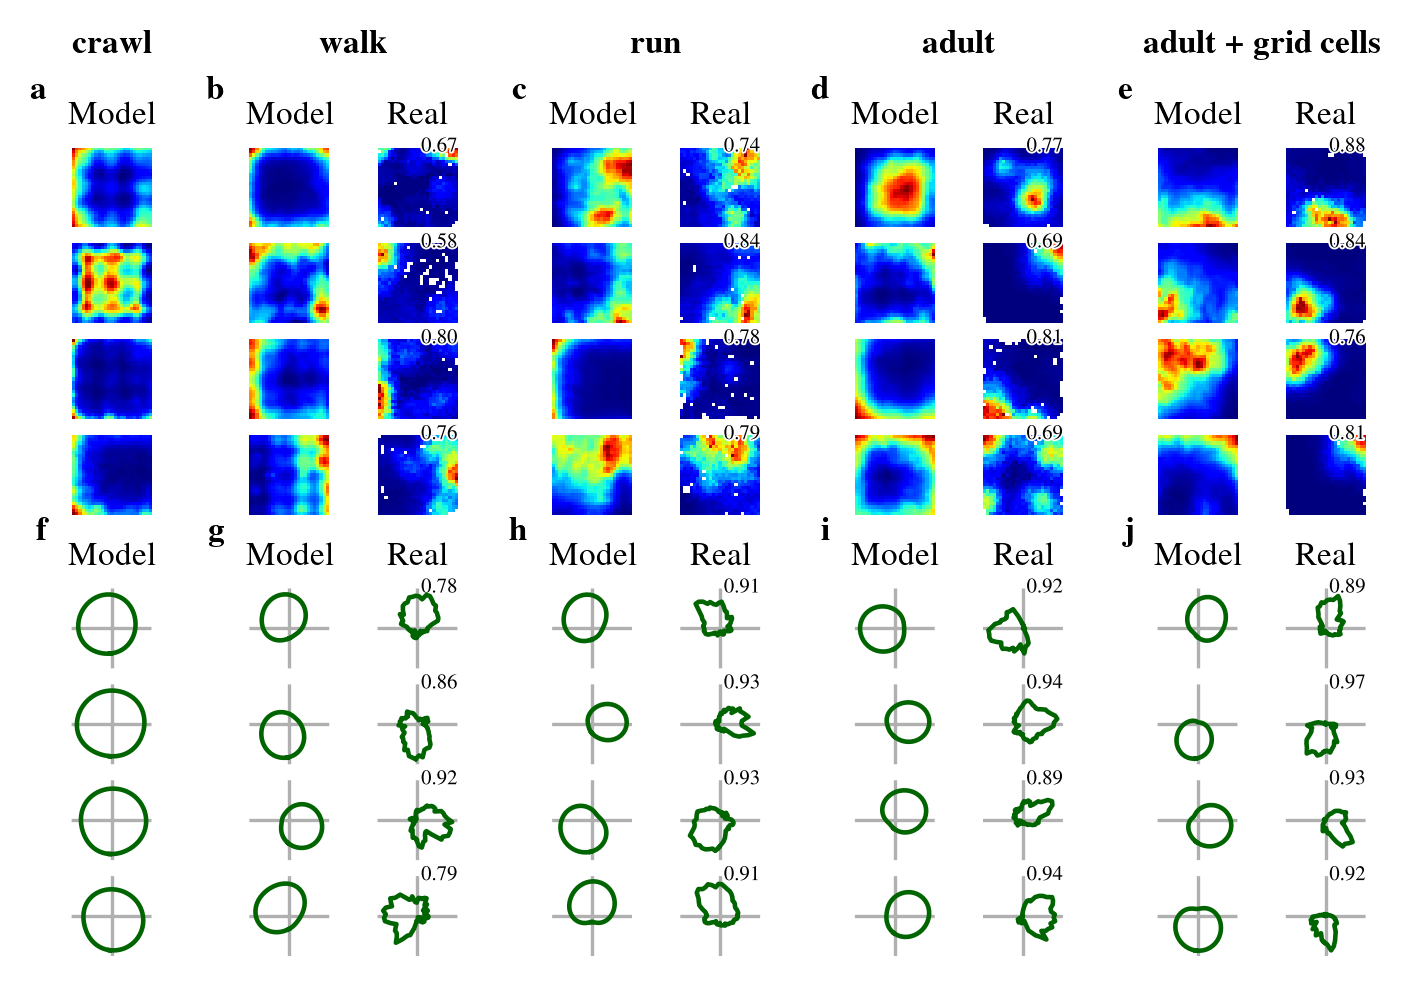

In [ ]:
import matplotlib.patheffects as patheffects

np.random.seed(12)

plt.style.use(os.path.join(BASE_DIR, 'matplotlib_style.mplstyle'))
plt.rcParams['text.latex.preamble'] = r'\usepackage{amsmath}'
plt.rcParams['text.usetex'] = True
plt.rcParams['text.latex.preamble'] = r'\usepackage{times}'
plt.rcParams['font.family'] = 'serif'

fig, axs = plt.subplots(2, 5, figsize=(4.6, 1.9+1.6), width_ratios=(1.05,2,2,2,2), dpi=300)

###############################################################
### PLOT ######################################################

annotations = ['a', 'b', 'c', 'd', 'e']
for i in range(len(pc_rm_model)):
    pc_rm_real_curr = None
    if i > 0 and i <= len(pc_rm_real):
        pc_rm_real_curr = pc_rm_real[i-1]
    elif i > len(pc_rm_real):
        pc_rm_real_curr = pc_rm_real[-1]

    pc_rm_model_curr = pc_rm_model[i]
    pc_si_model_curr = pc_si_model[i]

    pc_rm_corr = pc_rm_corr_list[i-1] if i > 0 else None
    # idx_model = np.argsort(pc_rm_corr.max(axis=1))[::-1]
    idx_model = np.arange(pc_rm_corr.shape[0]) if i > 0 else np.arange(pc_rm_model_curr.shape[0])
    np.random.shuffle(idx_model)

    if i != 0:
        idx_model_sel, idx_real_sel, corr_sel = [], [], []
        for im in idx_model:
            ir = pc_rm_corr[im].argmax()
            if ir in idx_real_sel:
                continue
            idx_model_sel.append(im)
            idx_real_sel.append(ir)
            corr_sel.append(pc_rm_corr[im, ir])
            if len(idx_model_sel) == 9:
                break
    else : idx_model_sel = idx_model

    ax = axs.flat[i]
    gs_c = ax.get_subplotspec()
    ax.set_axis_off()
    if i == 0:
        ax.set_title(r"\textbf{crawl}", y=1.19)
    elif i == 1:
        ax.set_title(r"\textbf{walk}", y=1.19)
    elif i == 2:
        ax.set_title(r"\textbf{run}", y=1.19)
    elif i == 3:
        ax.set_title(r"\textbf{adult}", y=1.19)
    else:
        ax.set_title(r"\textbf{adult + grid cells}", y=1.19)
        # ax.set_title(r"\textbf{adult with\\grid cells}", y=1.16)
    gs = ax.get_gridspec()
    gs.update(right=1.1)
    # fig.delaxes(ax)

    nested_gs = gs_c.subgridspec(4, 2, hspace=0.2, wspace=0) if i != 0 else gs_c.subgridspec(4, 1, hspace=0.2, wspace=0)

    c = 0
    for r in range(4):
        ax = fig.add_subplot(nested_gs[r, c])
        if r==0:
            if i == 0:
                ax.annotate(
                    r'\textbf{a}', xy=(0, 1), xycoords='axes fraction',
                    xytext=(-6, 10), textcoords='offset points',
                    ha='right', va='bottom'
                )
            elif i == 1:
                ax.annotate(
                    r'\textbf{b}', xy=(0, 1), xycoords='axes fraction',
                    xytext=(-6, 10), textcoords='offset points',
                    ha='right', va='bottom'
                )
            elif i == 2:
                ax.annotate(
                    r'\textbf{c}', xy=(0, 1), xycoords='axes fraction',
                    xytext=(-6, 10), textcoords='offset points',
                    ha='right', va='bottom'
                )
            elif i ==3:
                ax.annotate(
                    r'\textbf{d}', xy=(0, 1), xycoords='axes fraction',
                    xytext=(-6, 10), textcoords='offset points',
                    ha='right', va='bottom'
                )
            elif i ==4:
                ax.annotate(
                    r'\textbf{e}', xy=(0, 1), xycoords='axes fraction',
                    xytext=(-6, 10), textcoords='offset points',
                    ha='right', va='bottom'
                )
        if r==0:
            ax.set_title(f'Model', loc='center', pad=0, y=1.3, fontsize=8)
        ax.imshow(pc_rm_model_curr[idx_model_sel[r]], cmap='jet')
        ax.set_axis_off()

    if i != 0:
        c = 1
        for r in range(4):
            ax = fig.add_subplot(nested_gs[r, c])
            if r==0:
                ax.set_title(f'Real', loc='center', pad=0, y=1.3, fontsize=8)
            ax.imshow(pc_rm_real_curr[idx_real_sel[r]], cmap='jet')
            ax.set_title(
                f'{corr_sel[r]:.2f}', loc='right', pad=0, y=0.95,
                c='black', path_effects=[patheffects.withStroke(linewidth=0.9, foreground='white')],
                fontsize=5
            )
            ax.set_axis_off()


np.random.seed(5)
annotations = ['f', 'g', 'h', 'i', 'j']
for i in range(len(hdc_pm_model)):
    hdc_pm_real_curr = None
    hdc_rvl_real_curr = None
    if i > 0 and i <= len(hdc_pm_real):
        hdc_pm_real_curr = hdc_pm_real[i-1]
    elif i > len(hdc_pm_real):
        hdc_pm_real_curr = hdc_pm_real[-1]

    hdc_pm_model_curr = hdc_pm_model[i]
    hdc_rvl_model_curr = hdc_rvl_model[i]

    hdc_pm_corr = hdc_pm_corr_list[i-1] if i > 0 else None
    # idx_model = np.argsort(hdc_pm_corr.max(axis=1))[::-1]
    idx_model = np.arange(hdc_pm_corr.shape[0]) if i > 0 else np.arange(hdc_pm_model_curr.shape[0])
    np.random.shuffle(idx_model)

    if i != 0:
        idx_model_sel, idx_real_sel, corr_sel = [], [], []
        for im in idx_model:
            ir = hdc_pm_corr[im].argmax()
            if ir in idx_real_sel:
                continue
            idx_model_sel.append(im)
            idx_real_sel.append(ir)
            corr_sel.append(hdc_pm_corr[im, ir])
            if len(idx_model_sel) == 9:
                break
    else : idx_model_sel = idx_model

    ax = axs.flat[i+5]
    gs_c = ax.get_subplotspec()
    ax.set_axis_off()
    ax.set_title('', y=1.19)
    gs = ax.get_gridspec()
    gs.update(right=1.1)

    nested_gs = gs_c.subgridspec(4, 2, hspace=0.2, wspace=0) if i != 0 else gs_c.subgridspec(4, 1, hspace=0.2, wspace=0)

    c = 0
    for r in range(4):
        ax = fig.add_subplot(nested_gs[r, c], polar=True)
        if r==0:
            if i == 0:
                ax.annotate(
                    r'\textbf{f}', xy=(0, 1), xycoords='axes fraction',
                    xytext=(-6, 10), textcoords='offset points',
                    ha='right', va='bottom'
                )
            elif i == 1:
                ax.annotate(
                    r'\textbf{g}', xy=(0, 1), xycoords='axes fraction',
                    xytext=(-6, 10), textcoords='offset points',
                    ha='right', va='bottom'
                )
            elif i == 2:
                ax.annotate(
                    r'\textbf{h}', xy=(0, 1), xycoords='axes fraction',
                    xytext=(-6, 10), textcoords='offset points',
                    ha='right', va='bottom'
                )
            elif i ==3:
                ax.annotate(
                    r'\textbf{i}', xy=(0, 1), xycoords='axes fraction',
                    xytext=(-6, 10), textcoords='offset points',
                    ha='right', va='bottom'
                )
            elif i ==4:
                ax.annotate(
                    r'\textbf{j}', xy=(0, 1), xycoords='axes fraction',
                    xytext=(-6, 10), textcoords='offset points',
                    ha='right', va='bottom'
                )
        if r==0:
            ax.set_title(f'Model', loc='center', pad=0, y=1.3)
        pm = hdc_pm_model_curr[idx_model_sel[r]].copy()

        max_radius = np.max(pm)
        padding = max_radius * 0.15

        ax.plot(
            np.append(thetas_ticks, thetas_ticks[0]), # we want to close the circle
            np.append(pm, pm[0]), # we want to close the circle
            c='darkgreen', zorder=5, lw=1.1
            # marker='o', ms=5, mfc='red'
        )
        ax.set_xticklabels([]) # remove degrees indication
        ax.set_rticks([]) # add intensity indication
        ax.set_theta_direction(-1)
        ax.set_theta_zero_location('N') # move 0 to the north
        ax.set_rmax(max_radius + padding)
        ax.set_thetagrids([0, 90, 180, 270])
        ax.grid(True)
        ax.spines[['polar']].set_visible(False)

    if i != 0:
        c = 1
        for r in range(4):
            ax = fig.add_subplot(nested_gs[r, c], polar=True)
            if r==0:
                ax.set_title(f'Real', loc='center', pad=0, y=1.3)
            pm = hdc_pm_real_curr[idx_real_sel[r]].copy()

            max_radius = np.max(pm)
            padding = max_radius * 0.15

            ax.plot(
                np.append(thetas_ticks, thetas_ticks[0]), # we want to close the circle
                np.append(pm, pm[0]), # we want to close the circle
                c='darkgreen', zorder=5, lw=1.1
                # marker='o', ms=5, mfc='red'
            )
            ax.set_title(
                f'{corr_sel[r]:.2f}', loc='right', pad=0, y=0.95,
                c='black', path_effects=[patheffects.withStroke(linewidth=0.9, foreground='white')],
                fontsize=5
            )
            ax.set_xticklabels([]) # remove degrees indication
            ax.set_rticks([]) # add intensity indication
            ax.set_theta_direction(-1)
            ax.set_theta_zero_location('N') # move 0 to the north
            ax.set_rmax(max_radius + padding)
            ax.set_thetagrids([0, 90, 180, 270])
            ax.grid(True)
            ax.spines[['polar']].set_visible(False)

plt.tight_layout()

# from matplotlib._layoutgrid import plot_children
# plot_children(fig)
plt.savefig(os.path.join(BASE_DIR, 'paper_figures', 'neurons_rm_pm.pdf'), dpi=300, bbox_inches='tight', pad_inches=0.02)
plt.show()